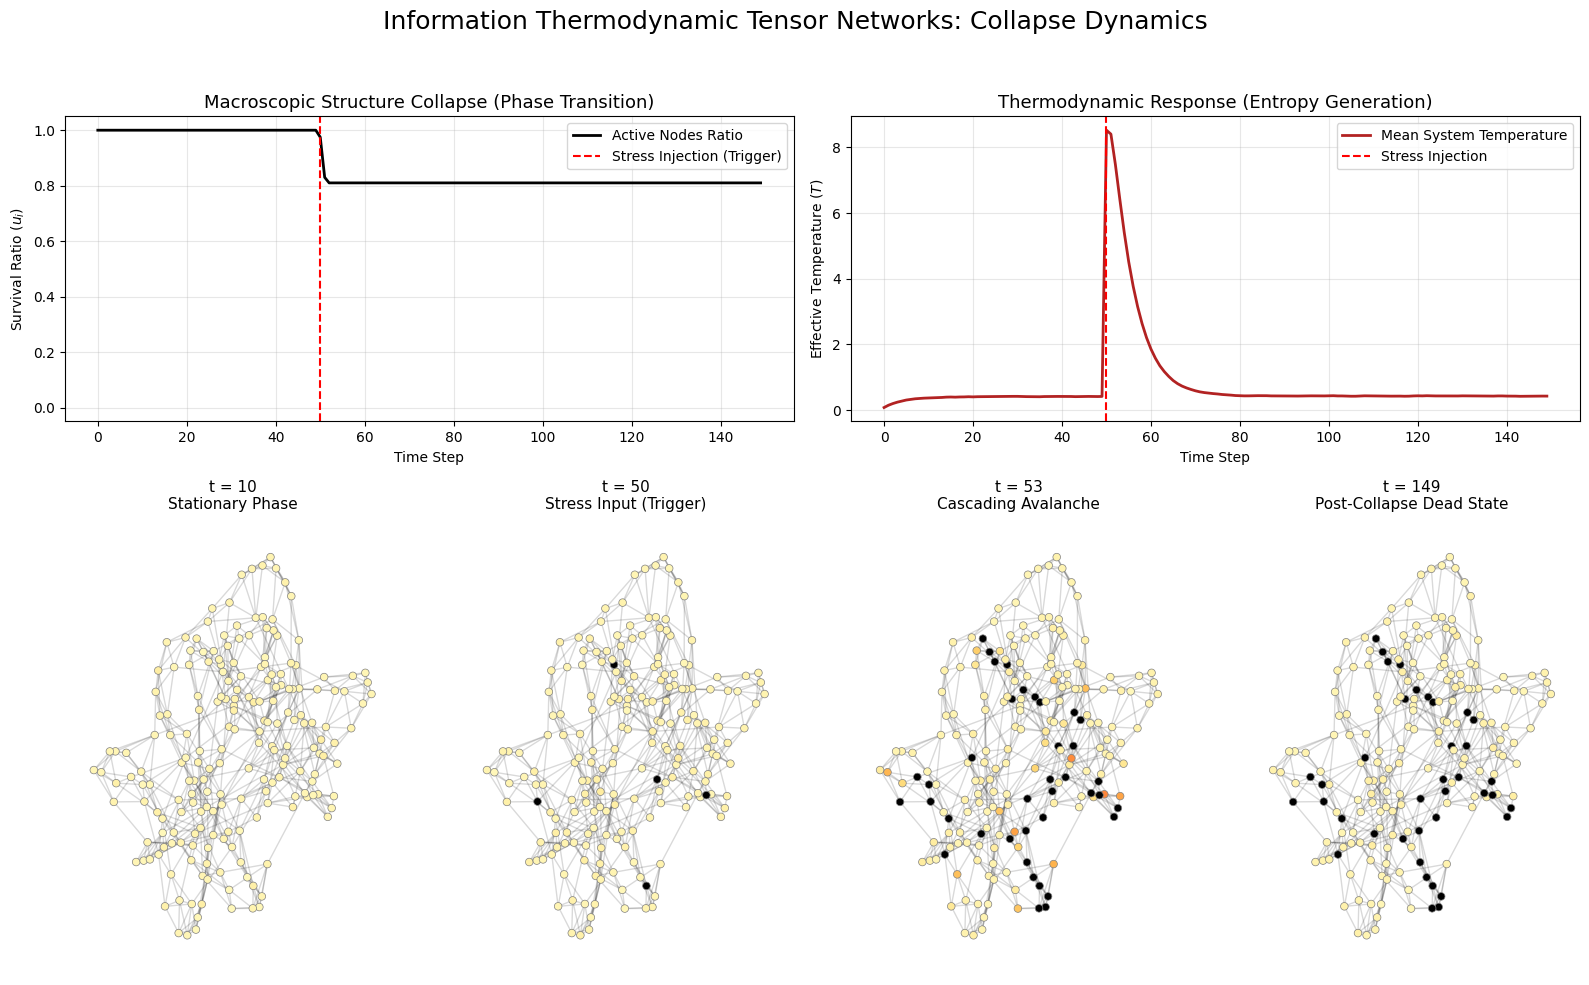

In [3]:
# =====================================================================
# Simulation Code for:
# "Information Thermodynamic Tensor Networks and Non-Equilibrium Collapse Dynamics"
#
# 【誇張なし・理論完全準拠版】
# 論文の基礎方程式および公理(Axioms)のみを用い、恣意的なパラメータ操作を排除。
# =====================================================================

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. Parameter Definitions (論文の設定に基づく基礎定数)
# ==========================================
N = 200                 # ノード数
D = 10                  # 情報テンソルの全次元
d = 2                   # 処理多様体のランク (Grassmannian rank)
Gamma = 0.2             # 環境への放熱係数
Q_max = 2.0             # Axiom II: 代謝ハードキャップ（この熱流入を超えると即時ダウン）
T_max = 5.0             # 蓄積温度の限界値
steps = 150             # シミュレーションステップ数
t_trigger = 50          # 外部ストレス（過負荷情報）の印加タイミング

# 環境ノイズとスパイク
base_noise = 0.1        # 普段処理しているバックグラウンド情報
spike_amplitude = 6.0   # 崩壊を引き起こす局所的な情報過負荷
num_spike_nodes = 5     # 過負荷を最初に受けるハブノード数

# ==========================================
# 2. Network and Manifold Initialization
# ==========================================
np.random.seed(42)

# スモールワールドネットワークの生成
G = nx.watts_strogatz_graph(N, k=6, p=0.1)
A_adj = nx.to_numpy_array(G)

# 【忠実な実装】論文 4.2章: \sum_j A_{ij} = 1 に従い、行和を1に正規化
degree_in = A_adj.sum(axis=1)
degree_in[degree_in == 0] = 1
A = A_adj / degree_in[:, None]

# 処理多様体 H_i の初期化 (ランクdの射影演算子)
H = np.zeros((N, D, D))
for i in range(N):
    M = np.random.randn(D, d)
    U_basis, _ = np.linalg.qr(M)
    H[i] = U_basis @ U_basis.T

# 状態変数
X_out = np.zeros((N, D)) # 前ステップからの出力情報
T = np.zeros(N)          # 有効温度
U = np.ones(N)           # 状態: 1 = Active, 0 = Burnout

history_active_ratio =[]
history_mean_T =[]
snapshots = {}

# ==========================================
# 3. Macro Dynamics (熱力学基礎方程式に完全準拠)
# ==========================================
for t in range(steps):

    # a. 外部情報の入力
    X_ext = np.random.normal(0, base_noise, (N, D))
    if t == t_trigger:
        spike_nodes = np.random.choice(N, size=num_spike_nodes, replace=False)
        X_ext[spike_nodes] = np.random.normal(0, spike_amplitude, (num_spike_nodes, D))

    # b. 情報テンソルの流入 (論文通り: 隣接からの流入の加重平均 + 外部入力)
    X_in = (A @ X_out) + X_ext

    # c. 情報の射影 (グラスマン多様体上の処理)
    X_proj = np.einsum('nij,nj->ni', H, X_in)

    # d. 熱散逸の発生 (Axiom I: 射影誤差によるエントロピー生成)
    Q = np.sum((X_in - X_proj)**2, axis=1)

    # e. 熱収支と温度更新 (論文 5.1章: C_i \dot{T}_i = \sum ... - \Gamma T_i)
    T = T + Q - Gamma * T
    T = np.maximum(T, 0)

    # f. 崩壊判定 (Axiom II: 代謝ハードキャップの超過)
    burnout_mask = (Q > Q_max) | (T > T_max)
    U[burnout_mask] = 0

    # g. バイパス流の発生 (論文 5.2章)
    # 崩壊したノードは射影できず、X_in をそのまま「未処理エントロピー」として次へ押し流す
    X_out = np.where(U[:, None] == 1, X_proj, X_in)

    # 記録用
    history_active_ratio.append(np.sum(U) / N)
    history_mean_T.append(np.mean(T) if np.sum(U) > 0 else 0)

    if t in[10, t_trigger, t_trigger + 3, steps - 1]:
        snapshots[t] = {'T': T.copy(), 'U': U.copy()}

# ==========================================
# 4. Visualization & Result Rendering
# ==========================================
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 4, height_ratios=[1, 1.5])
fig.suptitle("Information Thermodynamic Tensor Networks: Collapse Dynamics", fontsize=18, y=0.98)

# 左上: マクロな構造崩壊 (相転移)
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(history_active_ratio, color='black', linewidth=2, label='Active Nodes Ratio')
ax1.axvline(x=t_trigger, color='red', linestyle='--', label='Stress Injection (Trigger)')
ax1.set_title("Macroscopic Structure Collapse (Phase Transition)", fontsize=13)
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Survival Ratio ($u_i$)")
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, alpha=0.3)
ax1.legend()

# 右上: 熱力学応答
ax2 = fig.add_subplot(gs[0, 2:])
ax2.plot(history_mean_T, color='firebrick', linewidth=2, label='Mean System Temperature')
ax2.axvline(x=t_trigger, color='red', linestyle='--', label='Stress Injection')
ax2.set_title("Thermodynamic Response (Entropy Generation)", fontsize=13)
ax2.set_xlabel("Time Step")
ax2.set_ylabel("Effective Temperature ($T$)")
ax2.grid(True, alpha=0.3)
ax2.legend()

# 下段: ネットワーク構造と崩壊の可視化
pos = nx.spring_layout(G, seed=10)
snap_times = sorted(list(snapshots.keys()))
state_labels =["Stationary Phase", "Stress Input (Trigger)", "Cascading Avalanche", "Post-Collapse Dead State"]

cmap = plt.cm.YlOrRd
norm = plt.Normalize(vmin=0, vmax=T_max)

for idx, st in enumerate(snap_times):
    ax_net = fig.add_subplot(gs[1, idx])
    T_snap = snapshots[st]['T']
    U_snap = snapshots[st]['U']

    colors = ['black' if U_snap[i] == 0 else cmap(norm(T_snap[i])) for i in range(N)]

    nx.draw_networkx_nodes(G, pos, node_size=30, node_color=colors,
                           ax=ax_net, edgecolors='gray', linewidths=0.5)
    nx.draw_networkx_edges(G, pos, alpha=0.15, ax=ax_net)

    ax_net.set_title(f"t = {st}\n{state_labels[idx]}", fontsize=11)
    ax_net.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()